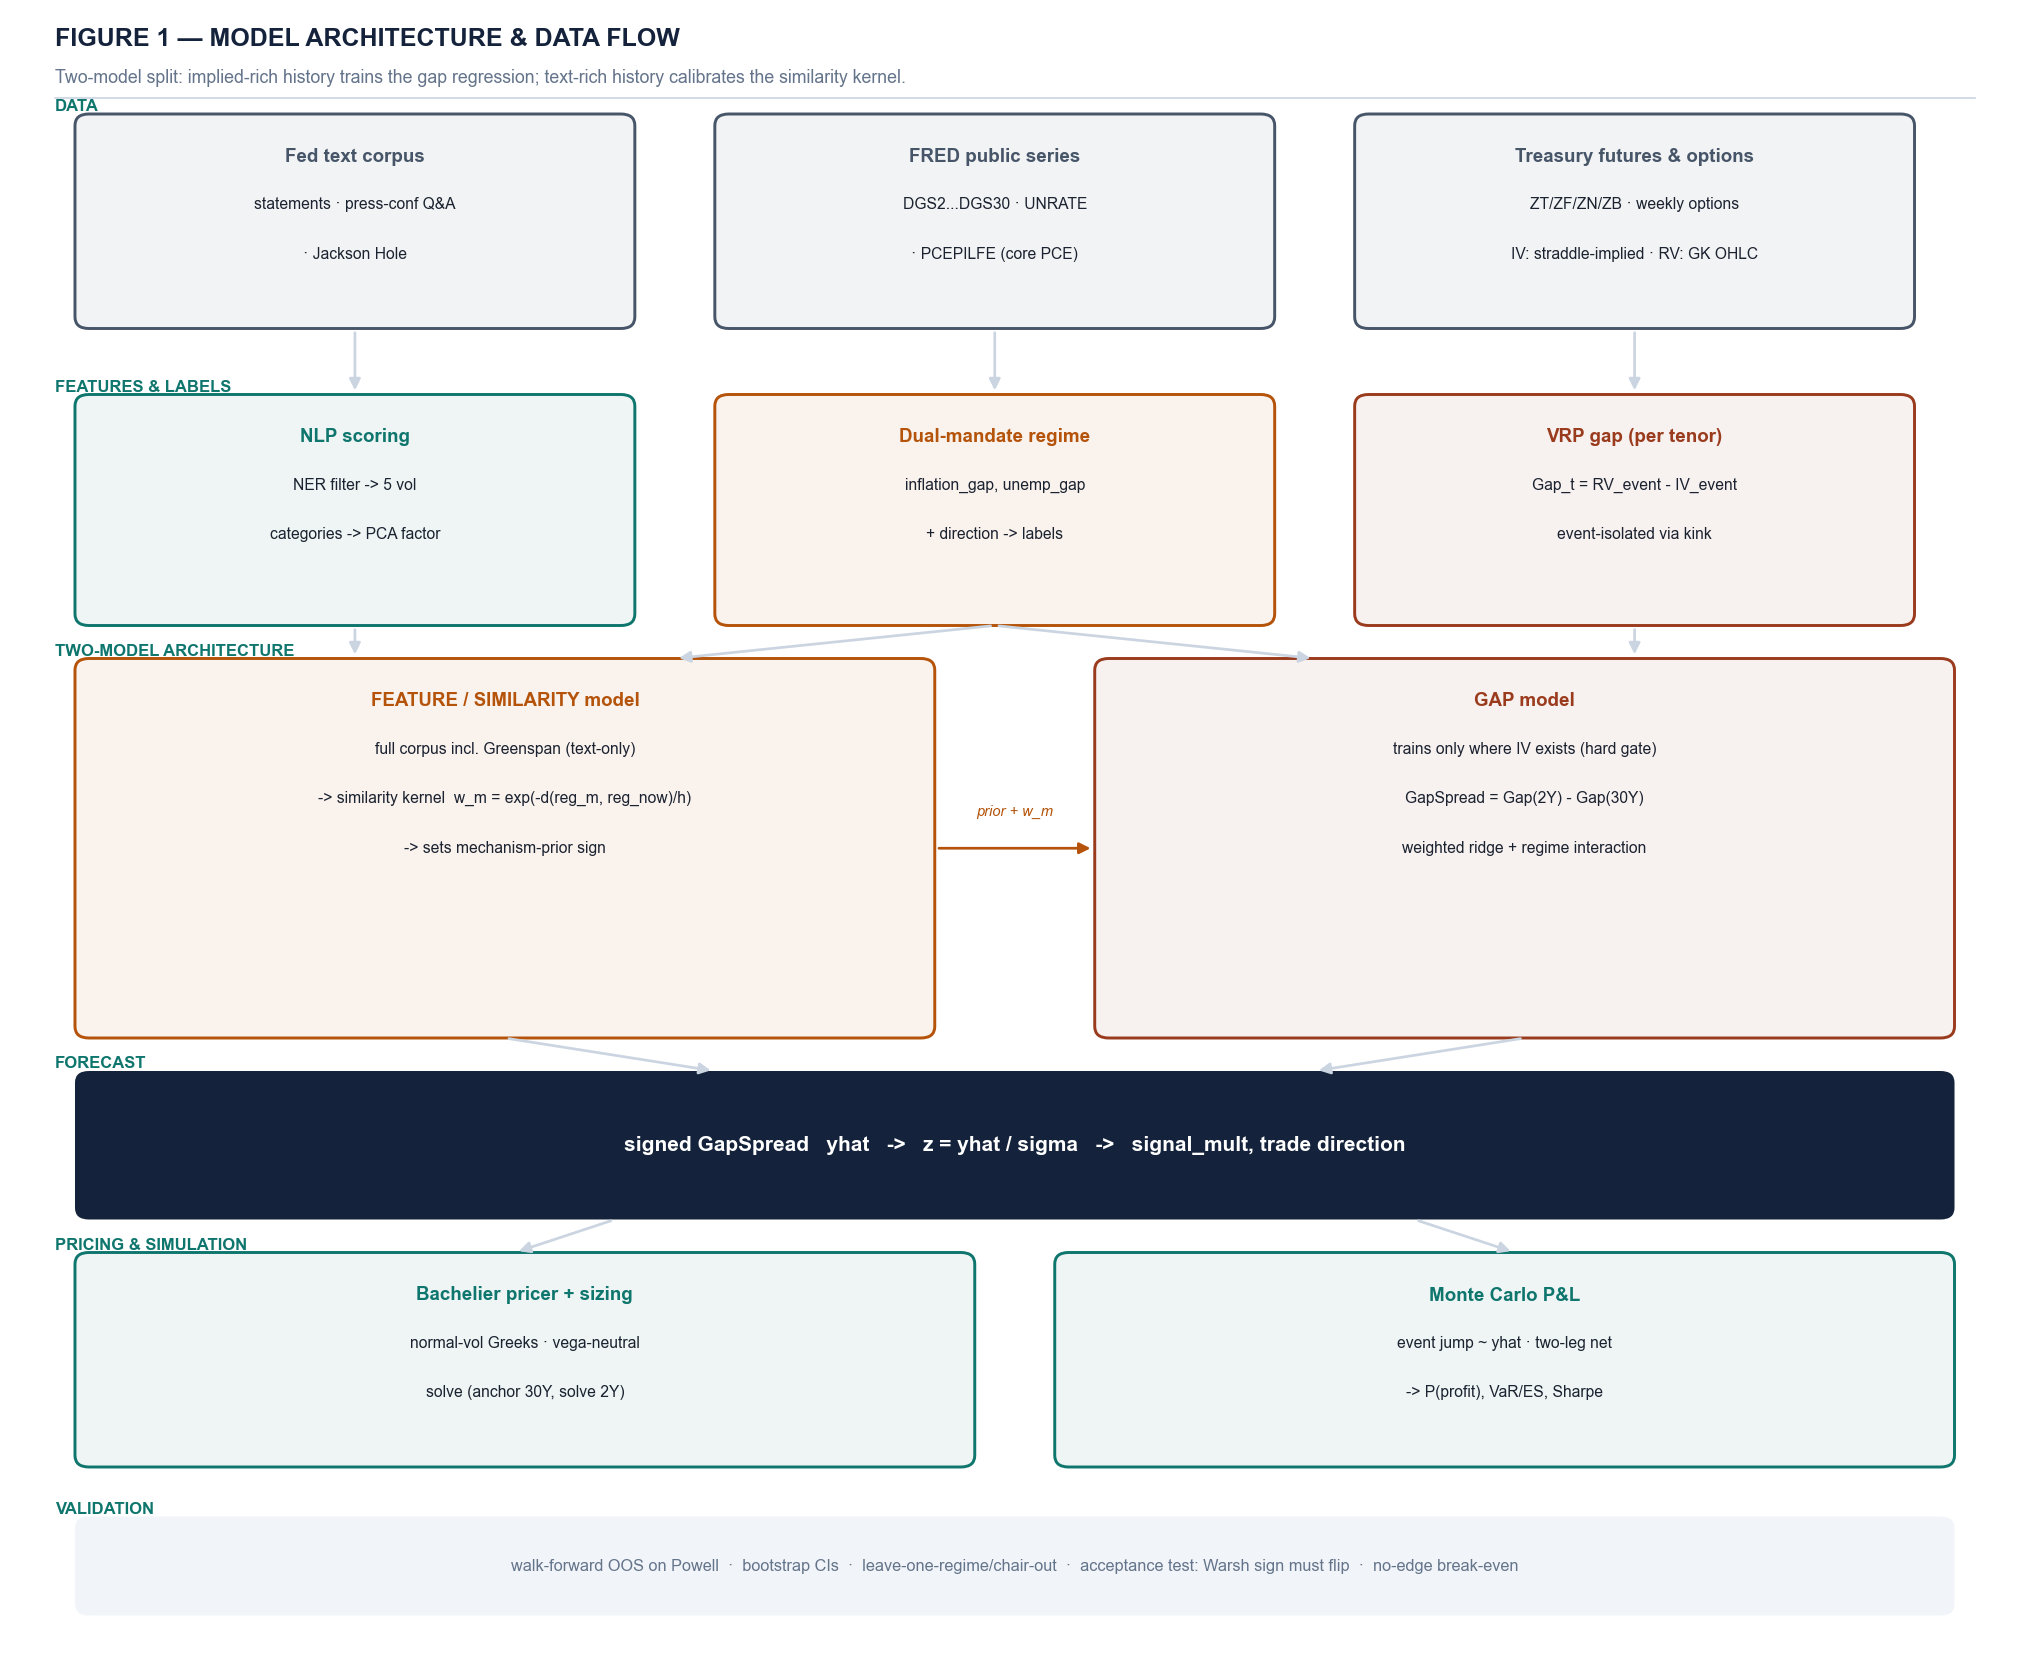

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK   = "#14233B"; TEAL  = "#0F766E"; AMBER = "#B45309"
CORAL = "#9A3B1D"; PAPER = "#FFFFFF"; TX    = "#1B2230"
MUTE  = "#64748B"; FAINT = "#CBD5E1"; SLATE = "#475569"
LIGHT = "#F1F5F9"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica Neue", "Helvetica", "DejaVu Sans"],
})

W, H = 13.33, 11.0
fig = plt.figure(figsize=(W, H), dpi=150)
ax  = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
fig.patch.set_facecolor(PAPER)

# ── helpers ───────────────────────────────────────────────────────────────────
def box(ax, x, y, w, h, title, lines, color, bg=0.07):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=0.7",
                 linewidth=1.4, edgecolor=color, facecolor=color, alpha=bg, zorder=2))
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=0.7",
                 linewidth=1.4, edgecolor=color, facecolor="none", zorder=3))
    ax.text(x+w/2, y+h-2.6, title,
            fontsize=9.0, color=color, fontweight="bold",
            ha="center", va="center", zorder=5)
    for i, ln in enumerate(lines):
        ax.text(x+w/2, y+h-5.5-i*3.0, ln,
                fontsize=7.5, color=TX, ha="center", va="center", zorder=5)

def dark_box(ax, x, y, w, h, text):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=0.7",
                 linewidth=0, facecolor=INK, zorder=2))
    ax.text(x+w/2, y+h/2, text,
            fontsize=10.0, color=PAPER, fontweight="bold",
            ha="center", va="center", zorder=5)

def light_box(ax, x, y, w, h, text):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=0.7",
                 linewidth=0, facecolor=LIGHT, zorder=2))
    ax.text(x+w/2, y+h/2, text,
            fontsize=7.8, color=MUTE, ha="center", va="center", zorder=5)

def section(ax, label, y):
    ax.text(2, y, label, fontsize=8.0, color=TEAL,
            fontweight="bold", va="bottom", zorder=6)

def arr(ax, x0, y0, x1, y1, color=FAINT, label=None, lx=None, ly=None):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1),
                 arrowstyle="-|>", mutation_scale=11,
                 linewidth=1.3, color=color, zorder=6))
    if label:
        ax.text(lx, ly, label, fontsize=7.0, color=color,
                ha="center", va="center", style="italic", zorder=7,
                bbox=dict(facecolor=PAPER, edgecolor="none", pad=1))

# ── layer y-bands: (bottom, top) ─────────────────────────────────────────────
D  = (81, 94)   # DATA
F  = (63, 77)   # FEATURES & LABELS
M  = (38, 61)   # TWO-MODEL
FC = (27, 36)   # FORECAST
P  = (12, 25)   # PRICING & SIMULATION
V  = (3,  9)    # VALIDATION

# ── figure title ─────────────────────────────────────────────────────────────
ax.text(2, 98.5, "FIGURE 1 — MODEL ARCHITECTURE & DATA FLOW",
        fontsize=12, color=INK, fontweight="bold", va="center")
ax.text(2, 96.2,
        "Two-model split: implied-rich history trains the gap regression; "
        "text-rich history calibrates the similarity kernel.",
        fontsize=8.5, color=MUTE, va="center")
ax.plot([2, 98], [95.0, 95.0], color=FAINT, lw=0.8)

# ── DATA ─────────────────────────────────────────────────────────────────────
section(ax, "DATA", D[1])
box(ax,  3, D[0], 28, D[1]-D[0], "Fed text corpus",
    ["statements · press-conf Q&A", "· Jackson Hole"], SLATE)
box(ax, 35, D[0], 28, D[1]-D[0], "FRED public series",
    ["DGS2...DGS30 · UNRATE", "· PCEPILFE (core PCE)"], SLATE)
box(ax, 67, D[0], 28, D[1]-D[0], "Treasury futures & options",
    ["ZT/ZF/ZN/ZB · weekly options", "IV: straddle-implied · RV: GK OHLC"], SLATE)

# ── FEATURES & LABELS ────────────────────────────────────────────────────────
section(ax, "FEATURES & LABELS", F[1])
box(ax,  3, F[0], 28, F[1]-F[0], "NLP scoring",
    ["NER filter -> 5 vol", "categories -> PCA factor"], TEAL)
box(ax, 35, F[0], 28, F[1]-F[0], "Dual-mandate regime",
    ["inflation_gap, unemp_gap", "+ direction -> labels"], AMBER)
box(ax, 67, F[0], 28, F[1]-F[0], "VRP gap (per tenor)",
    ["Gap_t = RV_event - IV_event", "event-isolated via kink"], CORAL)

# ── TWO-MODEL ARCHITECTURE ───────────────────────────────────────────────────
section(ax, "TWO-MODEL ARCHITECTURE", M[1])
box(ax,  3, M[0], 43, M[1]-M[0], "FEATURE / SIMILARITY model",
    ["full corpus incl. Greenspan (text-only)",
     "-> similarity kernel  w_m = exp(-d(reg_m, reg_now)/h)",
     "-> sets mechanism-prior sign"], AMBER)
box(ax, 54, M[0], 43, M[1]-M[0], "GAP model",
    ["trains only where IV exists (hard gate)",
     "GapSpread = Gap(2Y) - Gap(30Y)",
     "weighted ridge + regime interaction"], CORAL)

# ── FORECAST ─────────────────────────────────────────────────────────────────
section(ax, "FORECAST", FC[1])
dark_box(ax, 3, FC[0], 94, FC[1]-FC[0],
         "signed GapSpread   yhat   ->   z = yhat / sigma   ->   signal_mult, trade direction")

# ── PRICING & SIMULATION ──────────────────────────────────────────────────────
section(ax, "PRICING & SIMULATION", P[1])
box(ax,  3, P[0], 45, P[1]-P[0], "Bachelier pricer + sizing",
    ["normal-vol Greeks · vega-neutral", "solve (anchor 30Y, solve 2Y)"], TEAL)
box(ax, 52, P[0], 45, P[1]-P[0], "Monte Carlo P&L",
    ["event jump ~ yhat · two-leg net", "-> P(profit), VaR/ES, Sharpe"], TEAL)

# ── VALIDATION ────────────────────────────────────────────────────────────────
section(ax, "VALIDATION", V[1])
light_box(ax, 3, V[0], 94, V[1]-V[0],
          "walk-forward OOS on Powell  ·  bootstrap CIs  ·  leave-one-regime/chair-out  "
          "·  acceptance test: Warsh sign must flip  ·  no-edge break-even")

# ── arrows: DATA -> FEATURES ──────────────────────────────────────────────────
arr(ax, 17, D[0], 17, F[1])   # Fed text -> NLP
arr(ax, 49, D[0], 49, F[1])   # FRED -> Dual-mandate
arr(ax, 81, D[0], 81, F[1])   # Treasury -> VRP gap

# ── arrows: FEATURES -> TWO-MODEL ────────────────────────────────────────────
arr(ax, 17, F[0], 17, M[1])          # NLP -> FEATURE model
arr(ax, 49, F[0], 33, M[1])          # Dual-mandate -> FEATURE model
arr(ax, 49, F[0], 65, M[1])          # Dual-mandate -> GAP model
arr(ax, 81, F[0], 81, M[1])          # VRP gap -> GAP model

# ── FEATURE -> GAP (internal, horizontal) ────────────────────────────────────
my = (M[0]+M[1])/2
arr(ax, 46, my, 54, my, color=AMBER,
    label="prior + w_m", lx=50, ly=my+2.2)

# ── arrows: TWO-MODEL -> FORECAST ────────────────────────────────────────────
arr(ax, 24.5, M[0], 35, FC[1])       # FEATURE model -> Forecast
arr(ax, 75.5, M[0], 65, FC[1])       # GAP model -> Forecast

# ── arrows: FORECAST -> PRICING ──────────────────────────────────────────────
arr(ax, 30, FC[0], 25, P[1])         # Forecast -> Bachelier
arr(ax, 70, FC[0], 75, P[1])         # Forecast -> MC P&L

fig.savefig("ml_architecture.png", dpi=150, facecolor=PAPER,
            bbox_inches="tight", pad_inches=0.1)
plt.show()